# Dynamic Facial Expression Recognition with Facial Expression Activations

In [1]:
# Set up notebook
name_of_this_notebook = 'lstm-trajectories.ipynb.ipynb'

BATCH_SIZE = 32
SEED = 31

experiment_name = f'{name_of_this_notebook[:-6]}-seed-{SEED}'

In [2]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')

Notebook log filter installed (targeted, keeps Keras steps).


In [3]:
# import keras

# keras.mixed_precision.set_global_policy('mixed_float16')

In [4]:
# Ensure Determinism
import random
import numpy as np
import tensorflow as tf
import keras


random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

2026-09-12 20:13:49.851071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-12 20:13:49.859230: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-12 20:13:49.861854: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# Ensure GPU works as expected
print('TensorFlow Version:', tf.__version__, ';', 'Keras Version:', keras.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Number of GPUs detected: {len(gpus)}')
    for gpu in gpus:
        device_details = tf.config.experimental.get_device_details(gpu)
        print(f'Physical Device: {gpu.name}')
        print(f'Name: {device_details['device_name']}')
        print(f'Compute Capability: {device_details['compute_capability']}')
else:
    print('No GPUs were detected.')

TensorFlow Version: 2.17.0 ; Keras Version: 3.12.0
Number of GPUs detected: 1
Physical Device: /physical_device:GPU:0
Name: NVIDIA GeForce RTX 5090
Compute Capability: (12, 0)


## Prepare Data

In [6]:
from pathlib import Path
import pandas as pd

dataset_path = Path(r'/workspace/datasets/emoji-hero-vr-db-dfea-as-csv')

train_df = pd.read_csv(str(dataset_path / 'training_set.csv'))
print('train_df.shape:', train_df.shape)
val_df = pd.read_csv(str(dataset_path / 'validation_set.csv'))
print('val_df.shape:', val_df.shape)
test_df = pd.read_csv(str(dataset_path / 'test_set.csv'))
print('test_df.shape:', test_df.shape)
print('Columns:', test_df.columns)

train_df.shape: (28920, 66)
val_df.shape: (11550, 66)
test_df.shape: (11340, 66)
Columns: Index(['sequence_id', 'timestamp', 'BrowLowererL', 'BrowLowererR',
       'CheekPuffL', 'CheekPuffR', 'CheekRaiserL', 'CheekRaiserR',
       'CheekSuckL', 'CheekSuckR', 'ChinRaiserB', 'ChinRaiserT', 'DimplerL',
       'DimplerR', 'EyesClosedL', 'EyesClosedR', 'EyesLookDownL',
       'EyesLookDownR', 'EyesLookLeftL', 'EyesLookLeftR', 'EyesLookRightL',
       'EyesLookRightR', 'EyesLookUpL', 'EyesLookUpR', 'InnerBrowRaiserL',
       'InnerBrowRaiserR', 'JawDrop', 'JawSidewaysLeft', 'JawSidewaysRight',
       'JawThrust', 'LidTightenerL', 'LidTightenerR', 'LipCornerDepressorL',
       'LipCornerDepressorR', 'LipCornerPullerL', 'LipCornerPullerR',
       'LipFunnelerLB', 'LipFunnelerLT', 'LipFunnelerRB', 'LipFunnelerRT',
       'LipPressorL', 'LipPressorR', 'LipPuckerL', 'LipPuckerR',
       'LipStretcherL', 'LipStretcherR', 'LipSuckLB', 'LipSuckLT', 'LipSuckRB',
       'LipSuckRT', 'LipTightenerL', '

In [7]:
def prepare_data(df):
    grouped_by_sequence = df.groupby('sequence_id')

    sequences = []
    labels = []

    for sequence_id, group in grouped_by_sequence:
        sorted_group = group.sort_values(by='timestamp')
        sequences.append(sorted_group.iloc[:, 2:-1].values)  # Select all feature columns
        labels.append(sorted_group.iloc[0, -1])  # Select one label per group

    X = np.array(sequences)
    y = np.array(labels)
    return X, y


X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)
X_test, y_test = prepare_data(test_df)


print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (964, 30, 63)
X_val: (385, 30, 63)
X_test: (378, 30, 63)


In [8]:
def create_dataset(X, y, batch_size, reshuffle_each_iteration):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.shuffle(len(X), seed=SEED, reshuffle_each_iteration=reshuffle_each_iteration).batch(batch_size)
    return dataset


train_dataset = create_dataset(X_train, y_train, BATCH_SIZE, True)
val_dataset = create_dataset(X_val, y_val, BATCH_SIZE, False)
test_dataset = create_dataset(X_test, y_test, BATCH_SIZE, False)

In [9]:
id_to_emotion = {
    0: 'Anger',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happiness',
    4: 'Neutral',
    5: 'Sadness',
    6: 'Surprise',
}

class_names = list(id_to_emotion.values())

## Load the frozen best ordered model

In [31]:
from keras.models import load_model



model_path = Path(r'../fea_model.keras')

best_model = load_model(model_path)
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fea_input (InputLayer)          │ (None, 30, 63)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_in (Normalization)         │ (None, 30, 63)         │           127 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 30, 63)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_2 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,286 (1.32 MB)

 Trainable params: 115,719 (452.03 KB)

 Non-trainable params: 127 (512.00 B)

 Optimizer params: 231,440 (904.07 KB)

## Build a prefix version of exactly the same model

In [32]:
from keras.layers import Input
from keras.models import Model

prefix_input = Input(
    shape=(None, X_test.shape[-1]),
    name='prefix_input'
)

x = prefix_input

# Reuse every trained layer except the original fixed-size InputLayer.
for layer in best_model.layers[1:]:
    x = layer(x)

prefix_model = Model(
    inputs=prefix_input,
    outputs=x,
    name='fea_prefix_model'
)

prefix_model.summary()

Model: "fea_prefix_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ prefix_input (InputLayer)       │ (None, None, 63)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_in (Normalization)         │ (None, None, 63)       │           127 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, None, 63)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_2 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,846 (452.53 KB)

 Trainable params: 115,719 (452.03 KB)

 Non-trainable params: 127 (512.00 B)

### Verify that the prefix model is genuinely identical at 30 observations

In [33]:
original_predictions = best_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

prefix_predictions_30 = prefix_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

assert np.allclose(
    original_predictions,
    prefix_predictions_30,
    atol=1e-6
)

print(
    "Maximum prediction difference:",
    np.max(
        np.abs(
            original_predictions
            - prefix_predictions_30
        )
    )
)

print("Full-sequence predictions verified.")

Maximum prediction difference: 0.0
Full-sequence predictions verified.


## Generate prediction trajectories for all 30 prefix lengths

In [35]:
n_sequences = len(X_test)
sequence_length = X_test.shape[1]
n_classes = len(class_names)

prediction_trajectories = np.empty(
    (
        n_sequences,
        sequence_length,
        n_classes,
    ),
    dtype=np.float32
)

for timestep in range(1, sequence_length + 1):
    X_prefix = X_test[:, :timestep, :]

    prediction_trajectories[:, timestep - 1, :] = (
        prefix_model.predict(
            X_prefix,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print(
    "prediction_trajectories.shape:",
    prediction_trajectories.shape
)

print("prediction_trajectories[i, t, c] is the probability assigned to class c for sequence i after seeing observations 0 ... t.")

prediction_trajectories.shape: (378, 30, 7)
prediction_trajectories[i, t, c] is the probability assigned to class c for sequence i after seeing observations 0 ... t.


### Verify the final trajectory point once more

In [36]:
assert np.allclose(
    prediction_trajectories[:, -1, :],
    original_predictions,
    atol=1e-6
)

print("Final trajectory predictions match the original model.")

Final trajectory predictions match the original model.


### Save the complete trajectory data

In [67]:
rows = []

for sequence_index in range(n_sequences):
    true_class_id = int(y_test[sequence_index])
    true_class_name = id_to_emotion[true_class_id]

    for timestep in range(sequence_length):
        predicted_class_id = int(
            predicted_classes[
                sequence_index,
                timestep
            ]
        )

        row = {
            'sequence_index': sequence_index,
            'timestep': timestep + 1,
            'true_class_id': true_class_id,
            'true_class': true_class_name,
            'predicted_class_id': predicted_class_id,
            'predicted_class': id_to_emotion[
                predicted_class_id
            ],
            'true_class_probability': (
                true_class_probabilities[
                    sequence_index,
                    timestep
                ]
            ),
            'predicted_class_probability': (
                np.max(
                    prediction_trajectories[
                        sequence_index,
                        timestep
                    ]
                )
            ),
            'correct_at_timestep': (
                predicted_class_id
                == true_class_id
            ),
            'correct_final_prediction': bool(
                final_correct[sequence_index]
            ),
        }

        # Store the probability assigned to every class.
        for class_id, class_name in id_to_emotion.items():
            row[f'probability_{class_name.lower()}'] = (
                prediction_trajectories[
                    sequence_index,
                    timestep,
                    class_id
                ]
            )

        rows.append(row)

trajectory_df = pd.DataFrame(rows)

trajectory_df.to_csv(
    'fea_prediction_trajectories.csv',
    index=False
)

trajectory_df.head()

,sequence_index,timestep,true_class_id,true_class,predicted_class_id,predicted_class,true_class_probability,predicted_class_probability,correct_at_timestep,correct_final_prediction,probability_anger,probability_disgust,probability_fear,probability_happiness,probability_neutral,probability_sadness,probability_surprise
0,0,1,0,Anger,0,Anger,0.552614,0.552614,True,True,0.552614,0.108155,0.023265,0.025473,0.027096,0.204593,0.058803
1,0,2,0,Anger,0,Anger,0.773931,0.773931,True,True,0.773931,0.051726,0.003649,0.004114,0.004637,0.144593,0.017350
2,0,3,0,Anger,0,Anger,0.856087,0.856087,True,True,0.856087,0.030706,0.001105,0.001200,0.001416,0.101567,0.007921
3,0,4,0,Anger,0,Anger,0.893805,0.893805,True,True,0.893805,0.021771,0.000493,0.000502,0.000633,0.078230,0.004567
4,0,5,0,Anger,0,Anger,0.910399,0.910399,True,True,0.910399,0.018251,0.000301,0.000288,0.000381,0.067024,0.003357


## Compute overall accuracy as temporal evidence accumulates

In [37]:
predicted_classes = np.argmax(
    prediction_trajectories,
    axis=2
)

accuracy_by_timestep = np.mean(
    predicted_classes == y_test[:, None],
    axis=0
)

for timestep, accuracy in enumerate(
    accuracy_by_timestep,
    start=1
):
    print(
        f"{timestep:2d} observations: "
        f"{accuracy:.4f}"
    )

 1 observations: 0.2910
 2 observations: 0.3042
 3 observations: 0.3333
 4 observations: 0.3439
 5 observations: 0.3704
 6 observations: 0.3862
 7 observations: 0.3968
 8 observations: 0.4127
 9 observations: 0.4365
10 observations: 0.4603
11 observations: 0.4735
12 observations: 0.4841
13 observations: 0.4974
14 observations: 0.5053
15 observations: 0.5265
16 observations: 0.5556
17 observations: 0.5794
18 observations: 0.5952
19 observations: 0.6323
20 observations: 0.6534
21 observations: 0.6772
22 observations: 0.6984
23 observations: 0.7116
24 observations: 0.7275
25 observations: 0.7460
26 observations: 0.7593
27 observations: 0.7672
28 observations: 0.7778
29 observations: 0.7910
30 observations: 0.7831


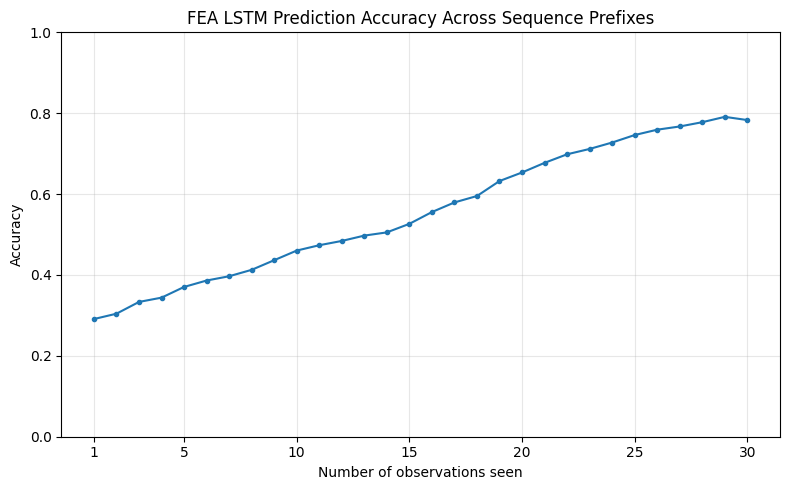

In [39]:
import matplotlib.pyplot as plt

timesteps = np.arange(1, sequence_length + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    timesteps,
    accuracy_by_timestep,
    marker='o',
    markersize=3
)

plt.xlabel('Number of observations seen')
plt.ylabel('Accuracy')
plt.title('FEA LSTM Prediction Accuracy Across Sequence Prefixes')

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Extract the probability assigned to the true class

In [40]:
true_class_probabilities = np.empty(
    (n_sequences, sequence_length),
    dtype=np.float32
)

for i in range(n_sequences):
    true_class_probabilities[i] = (
        prediction_trajectories[
            i,
            :,
            y_test[i]
        ]
    )

In [41]:
assert true_class_probabilities.shape == (378, 30)

## Plot mean true-class probability separately for each expression

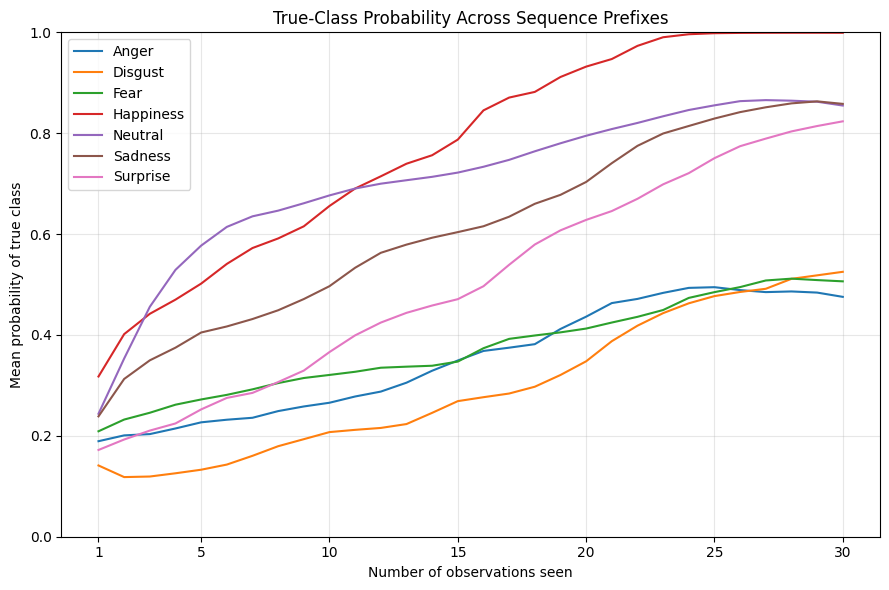

In [42]:
plt.figure(figsize=(9, 6))

for class_id, class_name in id_to_emotion.items():
    class_mask = y_test == class_id

    mean_probability = np.mean(
        true_class_probabilities[class_mask],
        axis=0
    )

    plt.plot(
        timesteps,
        mean_probability,
        label=class_name
    )

plt.xlabel('Number of observations seen')
plt.ylabel('Mean probability of true class')
plt.title('True-Class Probability Across Sequence Prefixes')

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Extract the probability assigned to the false class

In [53]:
false_class_probability_trajectories = {}

for class_id, class_name in id_to_emotion.items():
    # Only include sequences for which this class is false.
    false_class_mask = y_test != class_id

    mean_false_probability = np.mean(
        prediction_trajectories[
            false_class_mask,
            :,
            class_id
        ],
        axis=0
    )

    false_class_probability_trajectories[class_name] = (
        mean_false_probability
    )

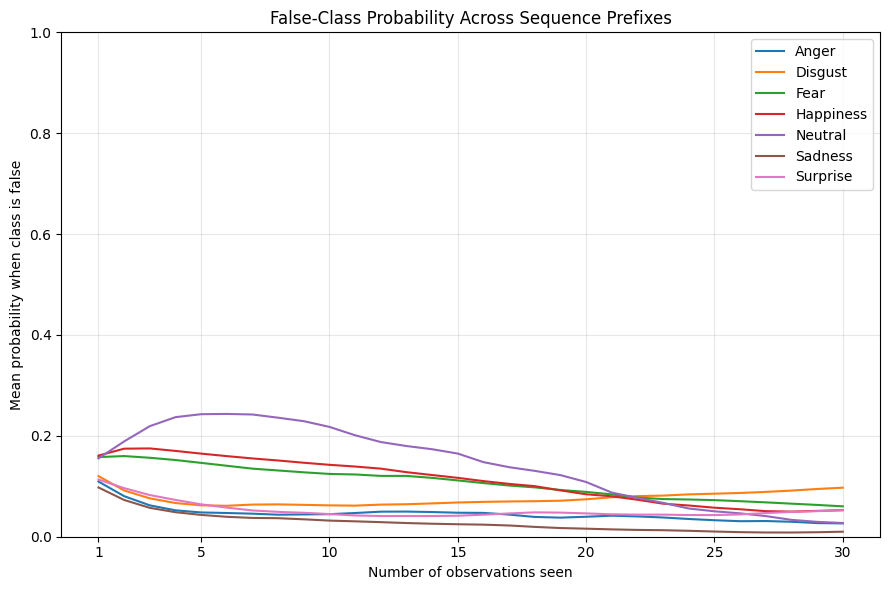

In [54]:
plt.figure(figsize=(9, 6))

for class_name, probabilities in (
    false_class_probability_trajectories.items()
):
    plt.plot(
        timesteps,
        probabilities,
        label=class_name
    )

plt.xlabel('Number of observations seen')
plt.ylabel('Mean probability when class is false')
plt.title('False-Class Probability Across Sequence Prefixes')

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Per-class analysis

In [56]:
def plot_class_probability_trajectories(
    true_class_id,
    prediction_trajectories,
    y_test,
    id_to_emotion
):
    true_class_name = id_to_emotion[true_class_id]

    class_mask = y_test == true_class_id

    plt.figure(figsize=(9, 6))

    for class_id, class_name in id_to_emotion.items():
        mean_probability = np.mean(
            prediction_trajectories[
                class_mask,
                :,
                class_id
            ],
            axis=0
        )

        plt.plot(
            timesteps,
            mean_probability,
            label=class_name
        )

    plt.xlabel('Number of observations seen')
    plt.ylabel('Mean predicted probability')
    plt.title(
        f'Prediction Probabilities for True {true_class_name} Sequences'
    )

    plt.xticks(
        [1, 5, 10, 15, 20, 25, 30]
    )

    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

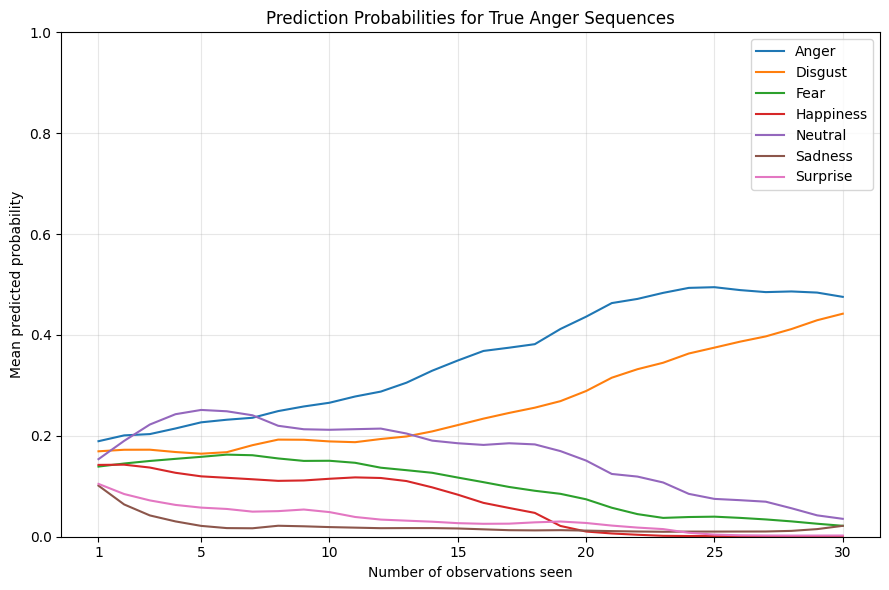

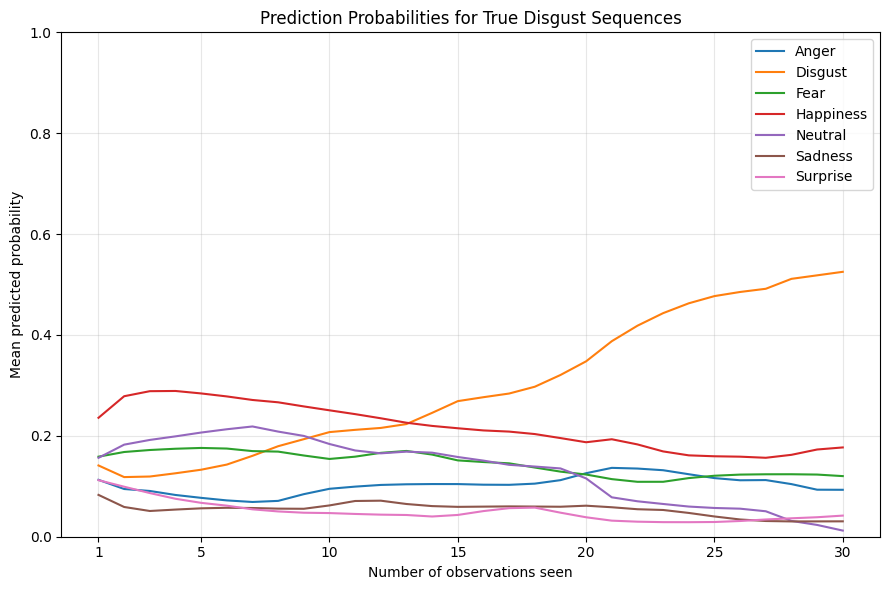

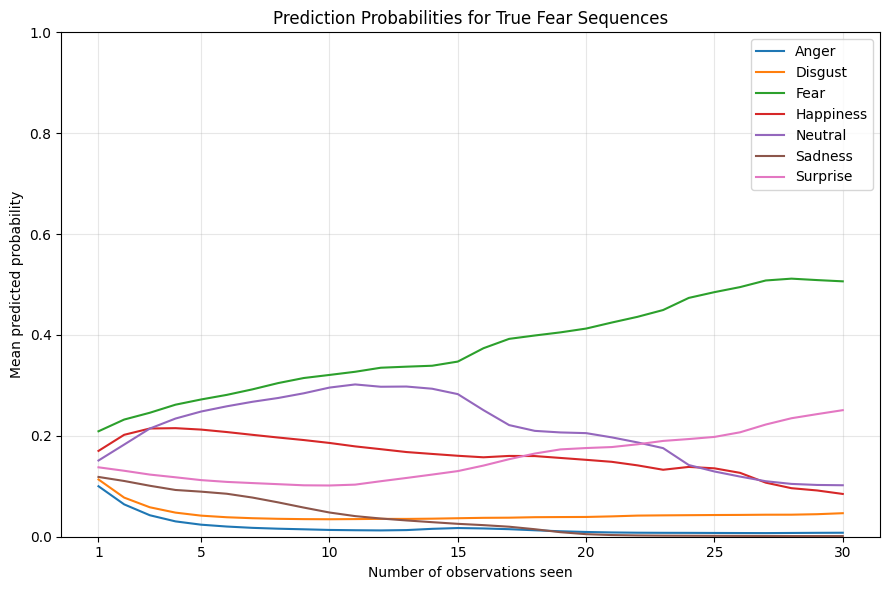

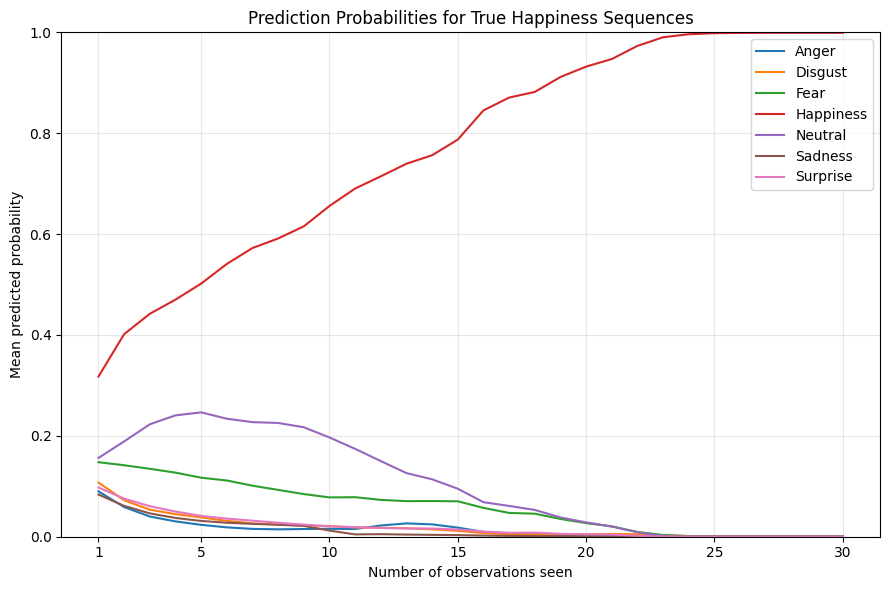

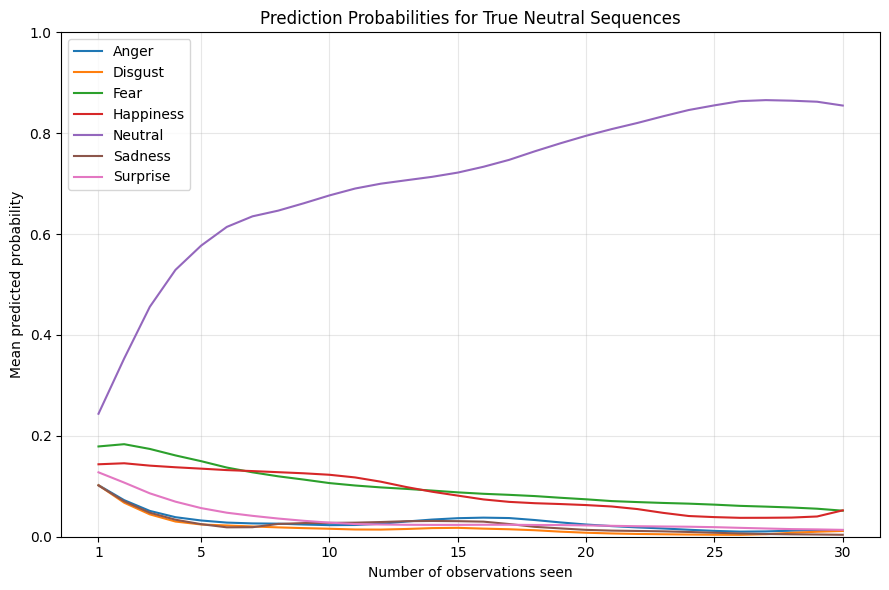

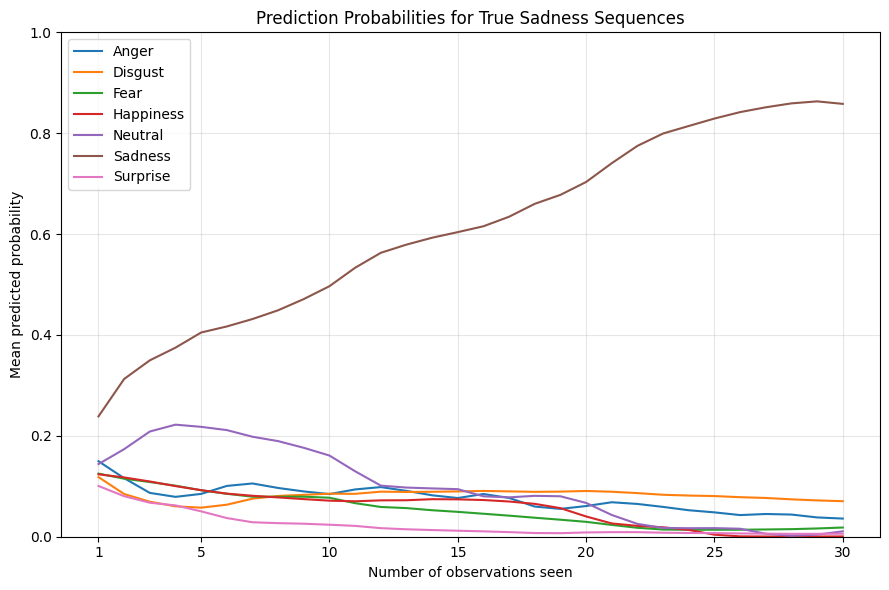

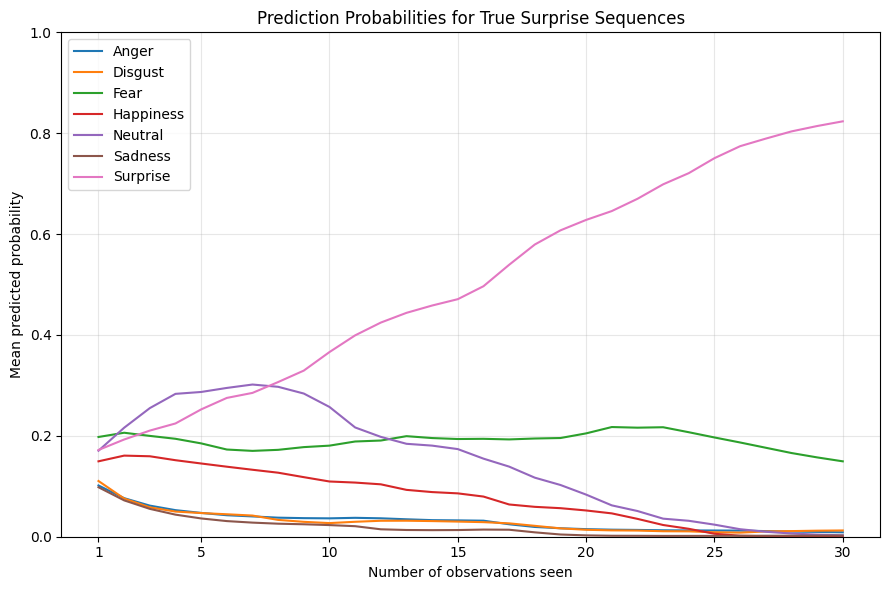

In [58]:
for class_id in id_to_emotion:
    plot_class_probability_trajectories(
        true_class_id=class_id,
        prediction_trajectories=prediction_trajectories,
        y_test=y_test,
        id_to_emotion=id_to_emotion
    )

## Plot class-wise accuracy trajectories

In [43]:
class_accuracy_trajectories = {}

for class_id, class_name in id_to_emotion.items():
    class_mask = y_test == class_id

    class_accuracy = np.mean(
        predicted_classes[class_mask]
        == y_test[class_mask, None],
        axis=0
    )

    class_accuracy_trajectories[class_name] = (
        class_accuracy
    )

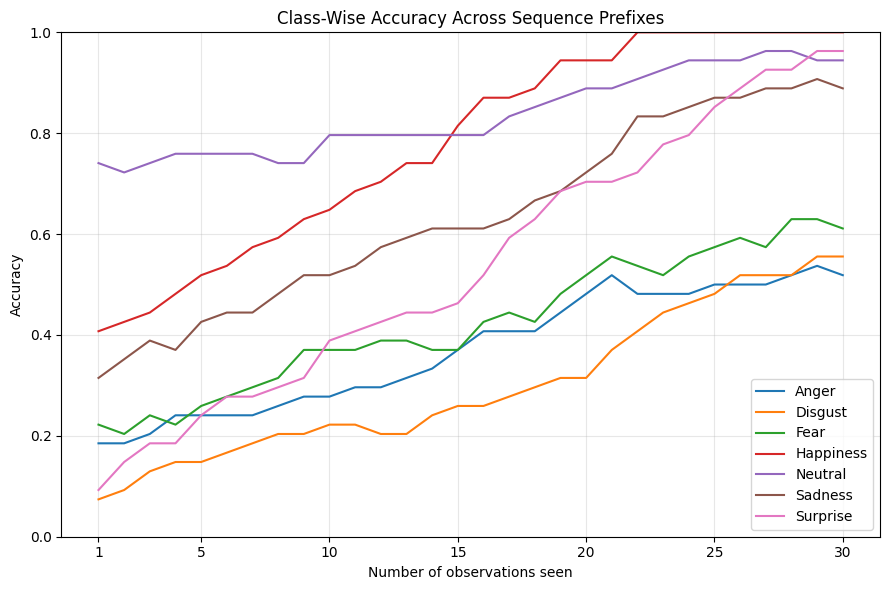

In [44]:
plt.figure(figsize=(9, 6))

for class_name, class_accuracy in (
    class_accuracy_trajectories.items()
):
    plt.plot(
        timesteps,
        class_accuracy,
        label=class_name
    )

plt.xlabel('Number of observations seen')
plt.ylabel('Accuracy')
plt.title('Class-Wise Recall Across Sequence Prefixes')

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Compare trajectory of number of predictions per class

In [68]:
prediction_counts = np.zeros(
    (sequence_length, len(id_to_emotion)),
    dtype=int
)

for timestep in range(sequence_length):
    for class_id in id_to_emotion:
        prediction_counts[timestep, class_id] = np.sum(
            predicted_classes[:, timestep] == class_id
        )

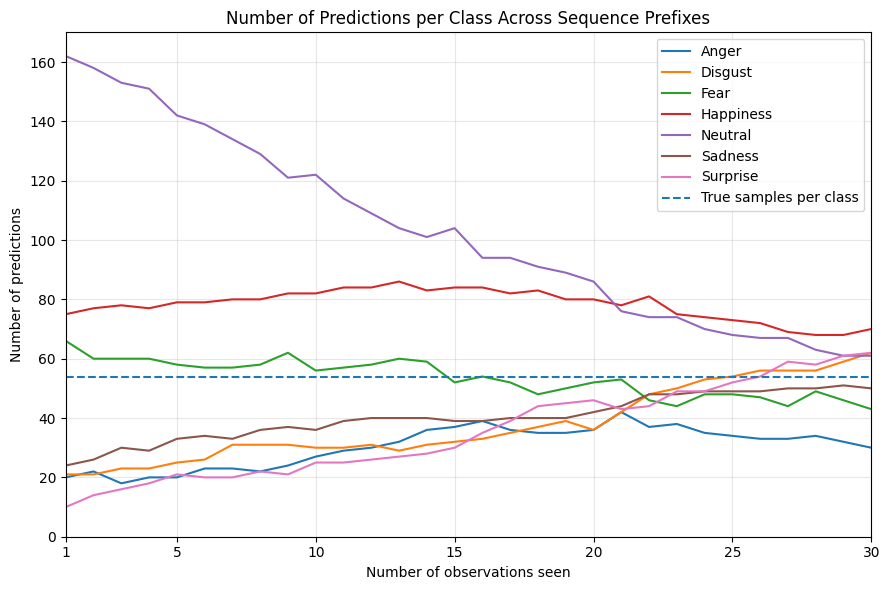

In [78]:
plt.figure(figsize=(9, 6))

for class_id, class_name in id_to_emotion.items():
    plt.plot(
        timesteps,
        prediction_counts[:, class_id],
        label=class_name
    )

plt.axhline(
    y=54,
    linestyle='--',
    label='True samples per class'
)

plt.xlabel('Number of observations seen')
plt.ylabel('Number of predictions')
plt.title('Number of Predictions per Class Across Sequence Prefixes')

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.xlim(1, 30)
plt.ylim(0, 170)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
assert np.all(
    prediction_counts.sum(axis=1) == len(y_test)
)

In [71]:
for timestep in [1, 5, 10, 15, 20, 25, 30]:
    print(f"\nTimestep {timestep}")

    for class_id, class_name in id_to_emotion.items():
        print(
            f"{class_name:10s}: "
            f"{prediction_counts[timestep - 1, class_id]}"
        )


Timestep 1
Anger     : 20
Disgust   : 21
Fear      : 66
Happiness : 75
Neutral   : 162
Sadness   : 24
Surprise  : 10

Timestep 5
Anger     : 20
Disgust   : 25
Fear      : 58
Happiness : 79
Neutral   : 142
Sadness   : 33
Surprise  : 21

Timestep 10
Anger     : 27
Disgust   : 30
Fear      : 56
Happiness : 82
Neutral   : 122
Sadness   : 36
Surprise  : 25

Timestep 15
Anger     : 37
Disgust   : 32
Fear      : 52
Happiness : 84
Neutral   : 104
Sadness   : 39
Surprise  : 30

Timestep 20
Anger     : 36
Disgust   : 36
Fear      : 52
Happiness : 80
Neutral   : 86
Sadness   : 42
Surprise  : 46

Timestep 25
Anger     : 34
Disgust   : 54
Fear      : 48
Happiness : 73
Neutral   : 68
Sadness   : 49
Surprise  : 52

Timestep 30
Anger     : 30
Disgust   : 62
Fear      : 43
Happiness : 70
Neutral   : 61
Sadness   : 50
Surprise  : 62


## Compare finally correct and finally incorrect sequences

In [49]:
final_predictions = predicted_classes[:, -1]

final_correct = final_predictions == y_test

print(
    "Finally correct:",
    np.sum(final_correct)
)

print(
    "Finally incorrect:",
    np.sum(~final_correct)
)

print(f"accuracy: {np.sum(final_correct) / len(final_correct)}")

Finally correct: 296
Finally incorrect: 82
accuracy: 0.783068783068783


In [50]:
correct_mean_probability = np.mean(
    true_class_probabilities[final_correct],
    axis=0
)

incorrect_mean_probability = np.mean(
    true_class_probabilities[~final_correct],
    axis=0
)

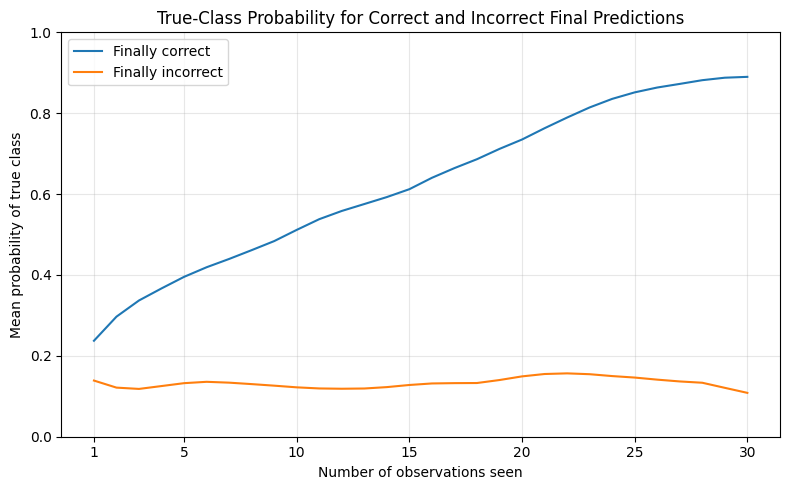

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    timesteps,
    correct_mean_probability,
    label='Finally correct'
)

plt.plot(
    timesteps,
    incorrect_mean_probability,
    label='Finally incorrect'
)

plt.xlabel('Number of observations seen')
plt.ylabel('Mean probability of true class')
plt.title(
    'True-Class Probability for Correct and Incorrect '
    'Final Predictions'
)

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Also compare prefix accuracy for those two groups

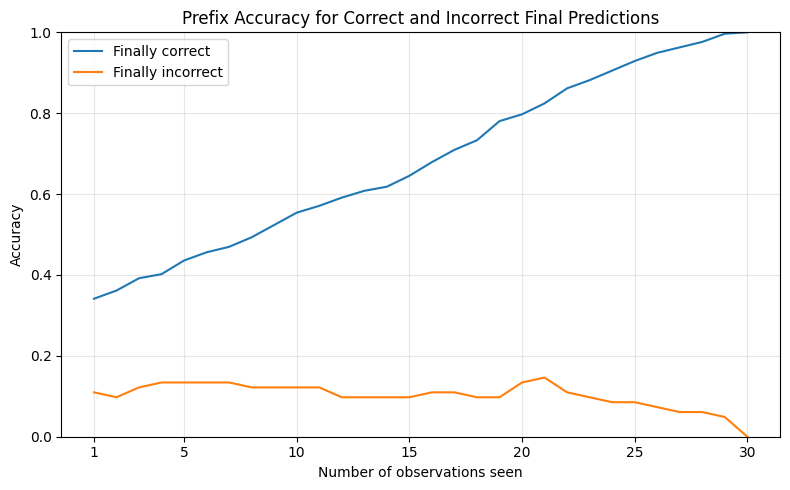

In [52]:
correct_group_accuracy = np.mean(
    predicted_classes[final_correct]
    == y_test[final_correct, None],
    axis=0
)

incorrect_group_accuracy = np.mean(
    predicted_classes[~final_correct]
    == y_test[~final_correct, None],
    axis=0
)

plt.figure(figsize=(8, 5))

plt.plot(
    timesteps,
    correct_group_accuracy,
    label='Finally correct'
)

plt.plot(
    timesteps,
    incorrect_group_accuracy,
    label='Finally incorrect'
)

plt.xlabel('Number of observations seen')
plt.ylabel('Accuracy')
plt.title(
    'Prefix Accuracy for Correct and Incorrect '
    'Final Predictions'
)

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Per class is more interesting

Anger: 28 correct, 26 incorrect


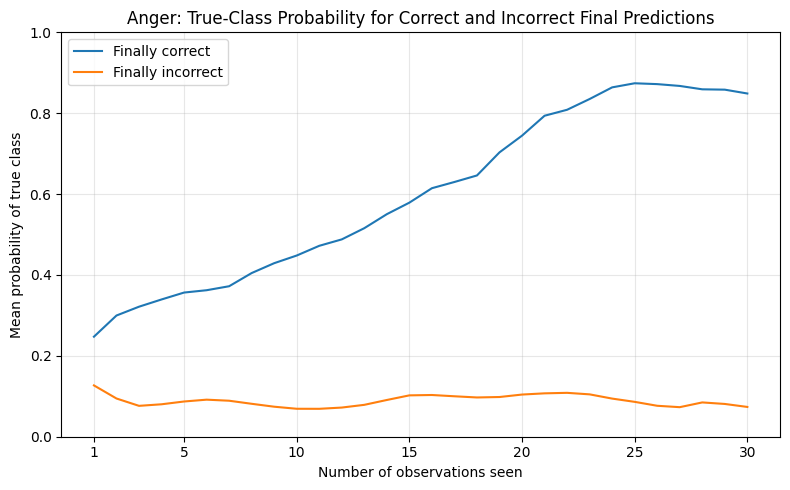

Disgust: 30 correct, 24 incorrect


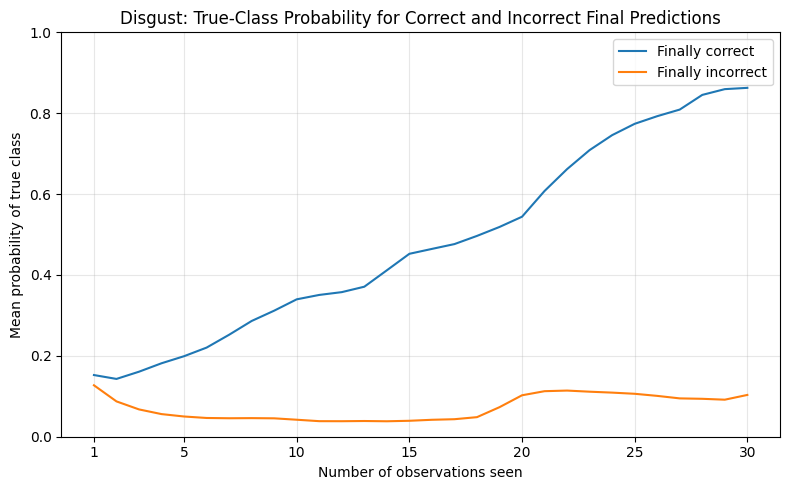

Fear: 33 correct, 21 incorrect


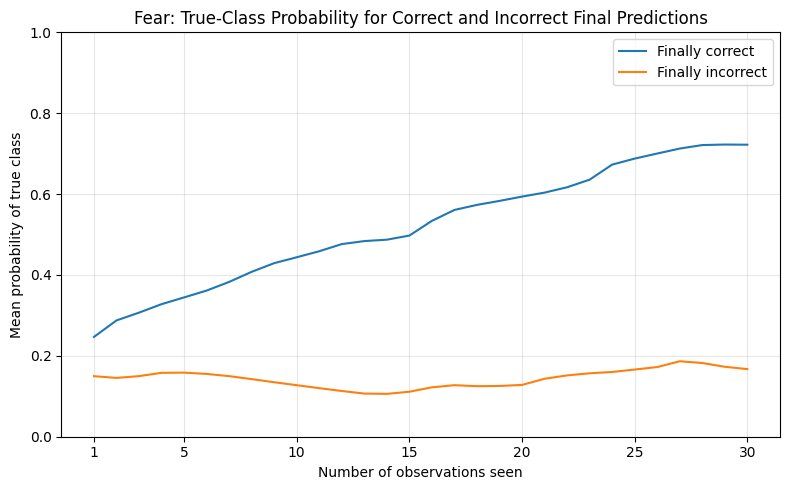

Happiness: 54 correct, 0 incorrect
Skipping Happiness: one group is empty.
Neutral: 51 correct, 3 incorrect


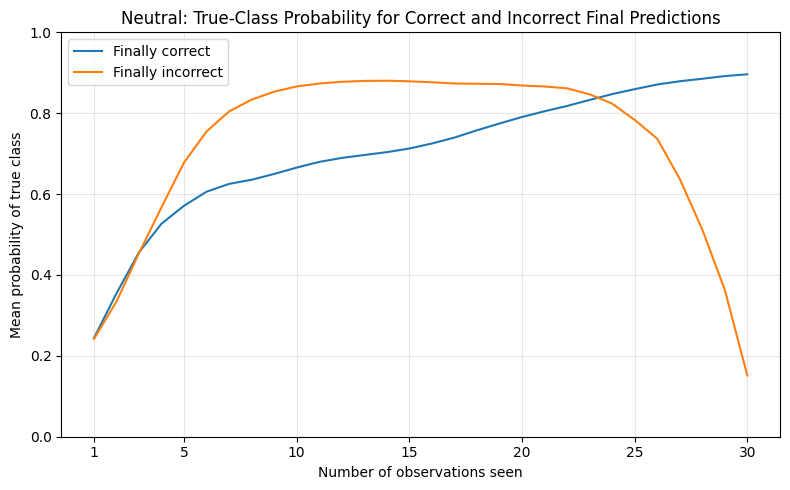

Sadness: 48 correct, 6 incorrect


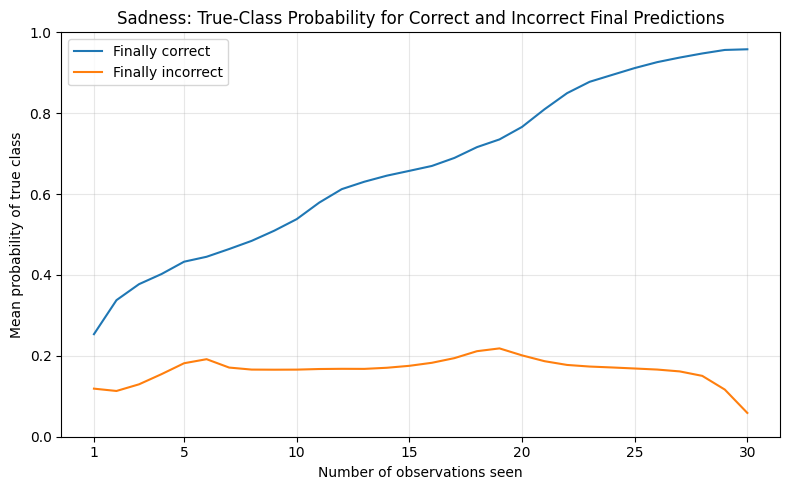

Surprise: 52 correct, 2 incorrect


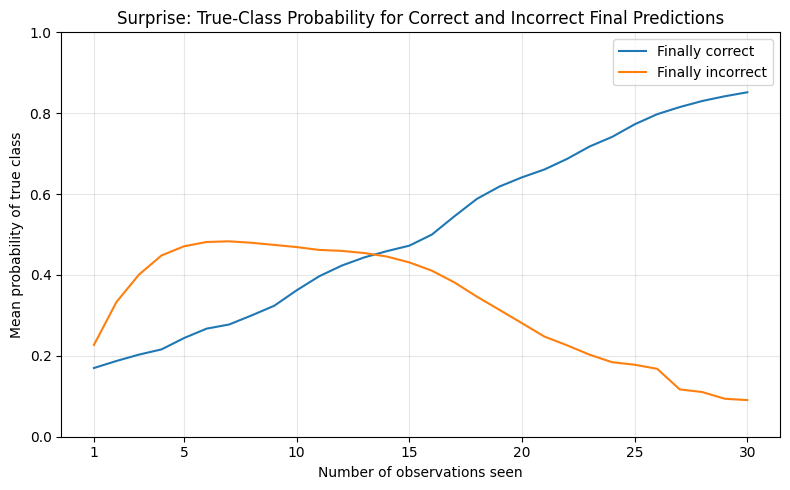

In [59]:
for class_id, class_name in id_to_emotion.items():
    class_mask = y_test == class_id

    class_correct_mask = class_mask & final_correct
    class_incorrect_mask = class_mask & ~final_correct

    print(
        f"{class_name}: "
        f"{np.sum(class_correct_mask)} correct, "
        f"{np.sum(class_incorrect_mask)} incorrect"
    )

    # Skip plotting if one group is empty.
    if (
        np.sum(class_correct_mask) == 0
        or np.sum(class_incorrect_mask) == 0
    ):
        print(f"Skipping {class_name}: one group is empty.")
        continue

    correct_mean_probability = np.mean(
        true_class_probabilities[class_correct_mask],
        axis=0
    )

    incorrect_mean_probability = np.mean(
        true_class_probabilities[class_incorrect_mask],
        axis=0
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        timesteps,
        correct_mean_probability,
        label='Finally correct'
    )

    plt.plot(
        timesteps,
        incorrect_mean_probability,
        label='Finally incorrect'
    )

    plt.xlabel('Number of observations seen')
    plt.ylabel('Mean probability of true class')
    plt.title(
        f'{class_name}: True-Class Probability for '
        'Correct and Incorrect Final Predictions'
    )

    plt.xticks(
        [1, 5, 10, 15, 20, 25, 30]
    )

    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [60]:
for class_id, class_name in id_to_emotion.items():
    class_mask = y_test == class_id

    class_accuracy = np.mean(
        final_correct[class_mask]
    )

    print(
        f"{class_name}: "
        f"{class_accuracy:.4f} "
        f"({np.sum(final_correct[class_mask])}/"
        f"{np.sum(class_mask)})"
    )

Anger: 0.5185 (28/54)
Disgust: 0.5556 (30/54)
Fear: 0.6111 (33/54)
Happiness: 1.0000 (54/54)
Neutral: 0.9444 (51/54)
Sadness: 0.8889 (48/54)
Surprise: 0.9630 (52/54)


## Let's look into the trajectories per class for just the finally incorrec samples 

In [61]:
for class_id, class_name in id_to_emotion.items():
    class_mask = y_test == class_id
    class_incorrect_mask = class_mask & ~final_correct

    print(
        f'{class_name}: '
        f'{np.sum(class_incorrect_mask)}/'
        f'{np.sum(class_mask)} finally incorrect'
    )

Anger: 26/54 finally incorrect
Disgust: 24/54 finally incorrect
Fear: 21/54 finally incorrect
Happiness: 0/54 finally incorrect
Neutral: 3/54 finally incorrect
Sadness: 6/54 finally incorrect
Surprise: 2/54 finally incorrect


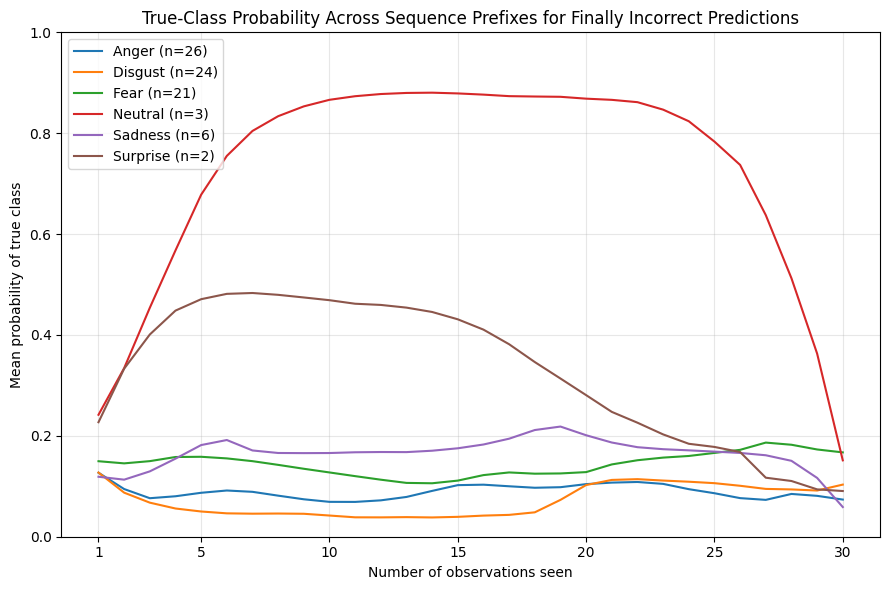

In [62]:
plt.figure(figsize=(9, 6))

for class_id, class_name in id_to_emotion.items():
    # Select sequences of this class that are incorrect after all 30 observations.
    class_incorrect_mask = (
        (y_test == class_id)
        & (~final_correct)
    )

    n_incorrect = np.sum(class_incorrect_mask)

    # Skip classes without any final misclassifications.
    if n_incorrect == 0:
        continue

    mean_probability = np.mean(
        true_class_probabilities[class_incorrect_mask],
        axis=0
    )

    plt.plot(
        timesteps,
        mean_probability,
        label=f'{class_name} (n={n_incorrect})'
    )

plt.xlabel('Number of observations seen')
plt.ylabel('Mean probability of true class')
plt.title(
    'True-Class Probability Across Sequence Prefixes '
    'for Finally Incorrect Predictions'
)

plt.xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
def plot_incorrect_class_trajectories(
    true_class_id,
    prediction_trajectories,
    y_test,
    final_correct,
    id_to_emotion,
    timesteps
):
    true_class_name = id_to_emotion[true_class_id]

    # Select only samples of this true class that are finally misclassified.
    incorrect_mask = (
        (y_test == true_class_id)
        & (~final_correct)
    )

    n_incorrect = np.sum(incorrect_mask)

    print(
        f"{true_class_name}: "
        f"{n_incorrect} finally incorrect samples"
    )

    if n_incorrect == 0:
        print("No incorrect samples to plot.")
        return

    plt.figure(figsize=(9, 6))

    for predicted_class_id, predicted_class_name in id_to_emotion.items():
        mean_probability = np.mean(
            prediction_trajectories[
                incorrect_mask,
                :,
                predicted_class_id
            ],
            axis=0
        )

        plt.plot(
            timesteps,
            mean_probability,
            label=predicted_class_name
        )

    plt.xlabel('Number of observations seen')
    plt.ylabel('Mean predicted probability')
    plt.title(
        f'Prediction Probabilities for Finally Incorrect '
        f'{true_class_name} Sequences (n={n_incorrect})'
    )

    plt.xticks(
        [1, 5, 10, 15, 20, 25, 30]
    )

    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Anger: 26 finally incorrect samples


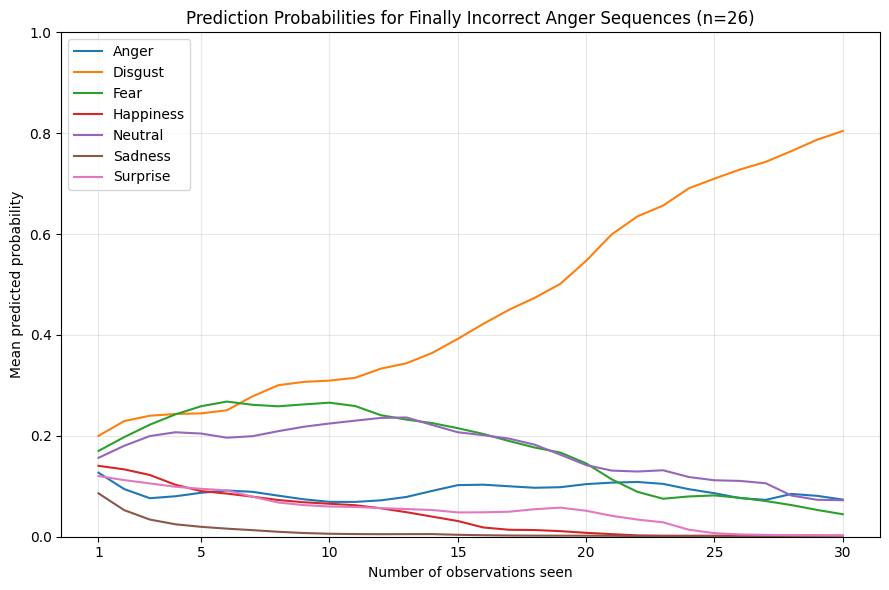

Disgust: 24 finally incorrect samples


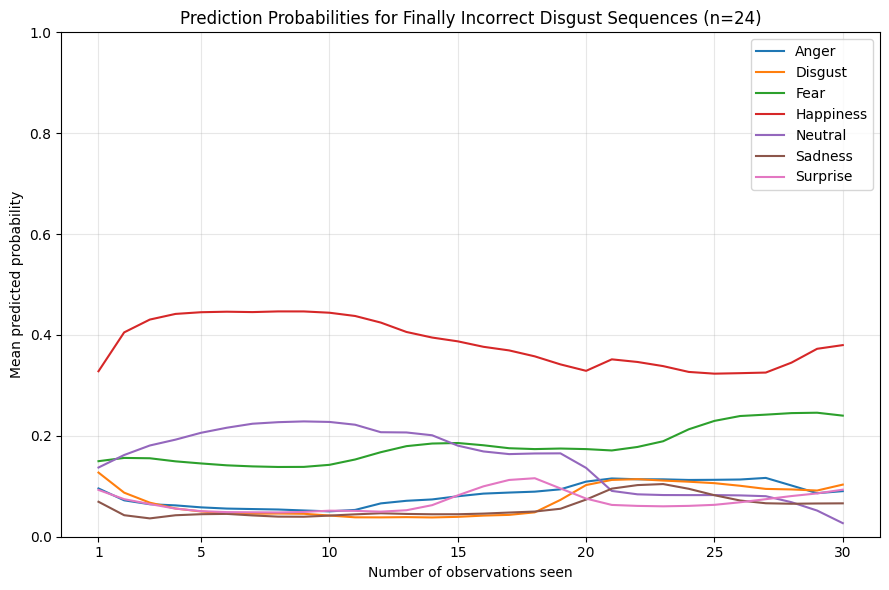

Fear: 21 finally incorrect samples


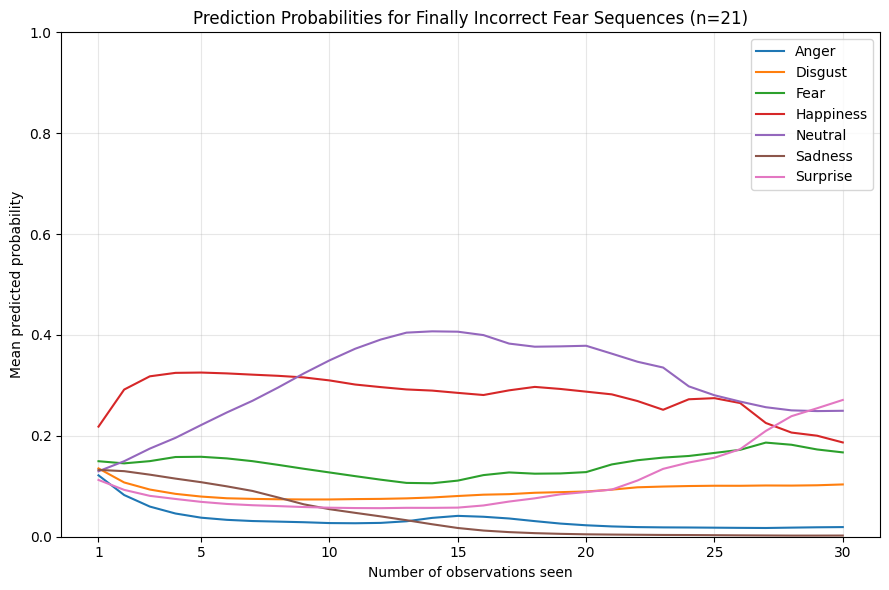

Happiness: 0 finally incorrect samples
No incorrect samples to plot.
Neutral: 3 finally incorrect samples


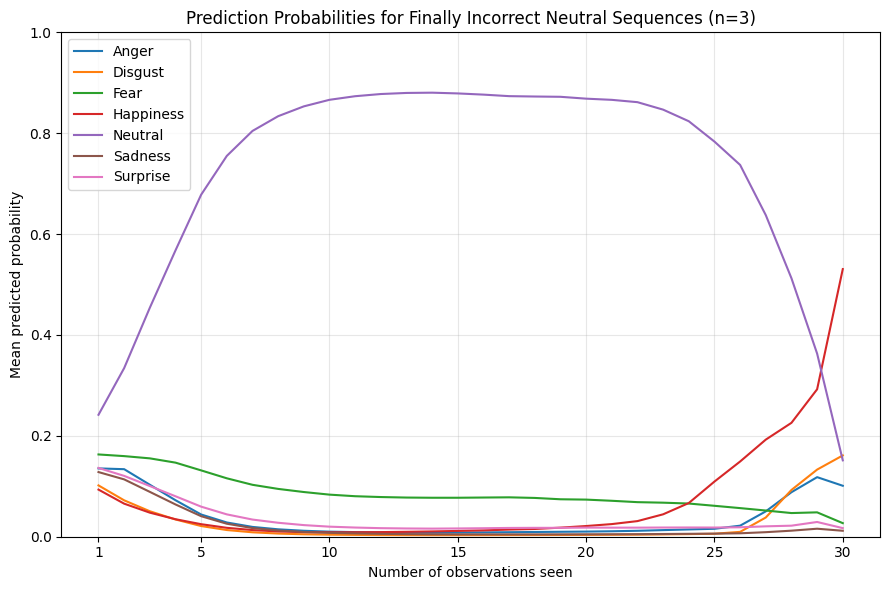

Sadness: 6 finally incorrect samples


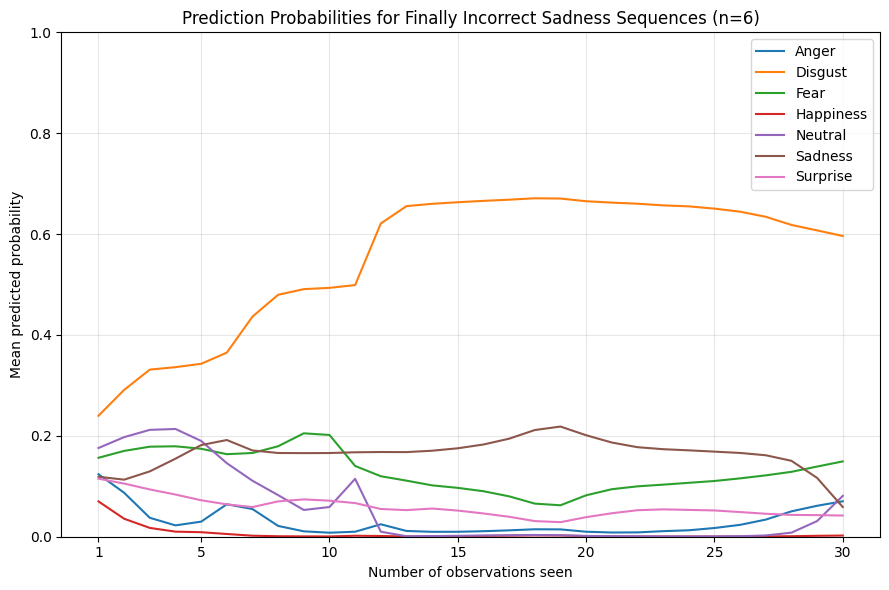

Surprise: 2 finally incorrect samples


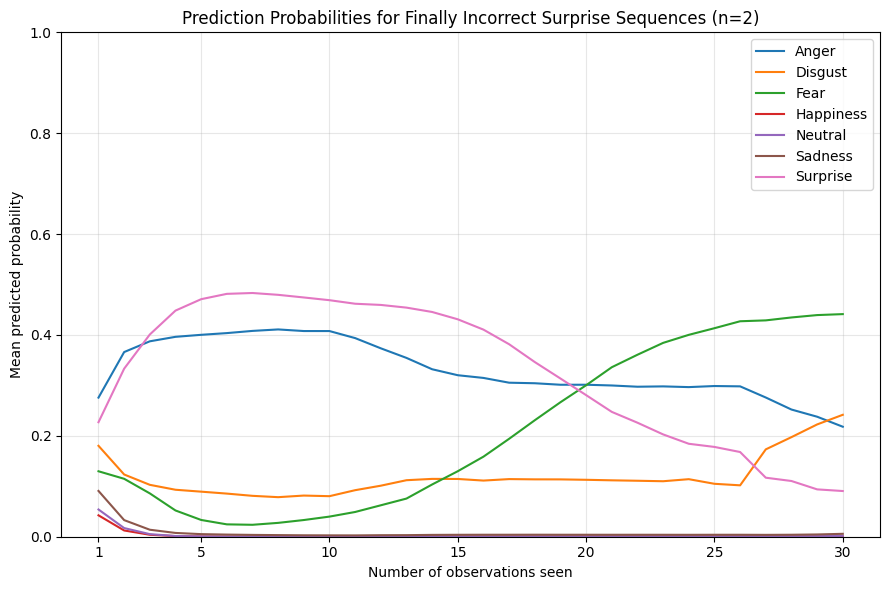

In [64]:
for class_id in id_to_emotion:
    plot_incorrect_class_trajectories(
        true_class_id=class_id,
        prediction_trajectories=prediction_trajectories,
        y_test=y_test,
        final_correct=final_correct,
        id_to_emotion=id_to_emotion,
        timesteps=timesteps
    )

## Plot all sample probability trajectories peer class 

In [143]:
def plot_sample_true_class_trajectories(
    trajectory_df,
    class_name
):
    class_df = trajectory_df[
        trajectory_df['true_class'] == class_name
    ]

    plt.figure(figsize=(9, 6))

    color = 'tab:blue'

    # Plot all individual sample trajectories in the same semi-transparent color.
    for sequence_index, sequence_df in class_df.groupby('sequence_index'):
        plt.plot(
            sequence_df['timestep'],
            sequence_df['true_class_probability'],
            color=color,
            alpha=0.08,
            linewidth=5
        )

    # Plot the mean trajectory more prominently.
    mean_trajectory = (
        class_df
        .groupby('timestep')['true_class_probability']
        .mean()
    )

    plt.plot(
        mean_trajectory.index,
        mean_trajectory.values,
        color=color,
        linewidth=5,
        label='Mean'
    )

    plt.xlabel('Number of observations seen')
    plt.ylabel('Probability of true class')
    plt.title(
        f'True-Class Probability Across Sequence Prefixes: '
        f'{class_name}'
    )

    plt.xticks([1, 5, 10, 15, 20, 25, 30])
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

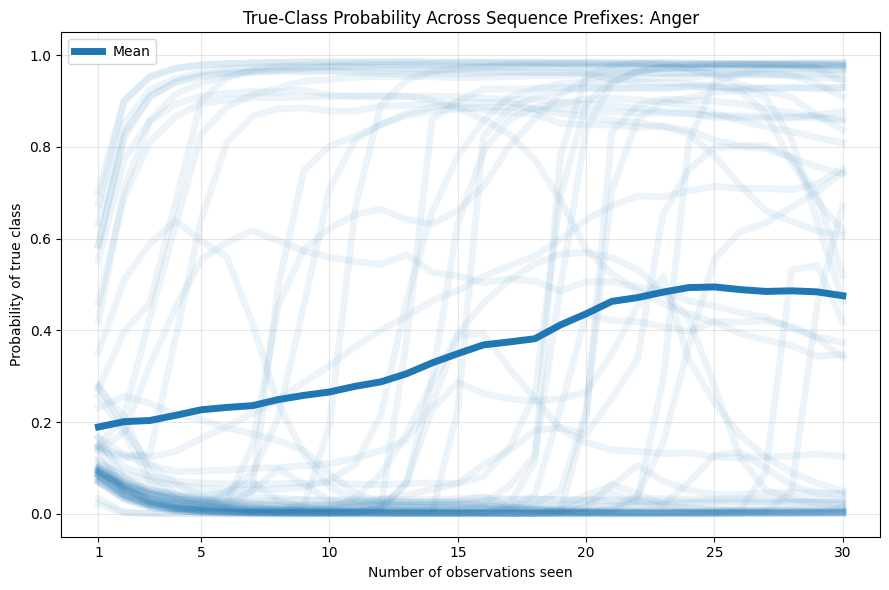

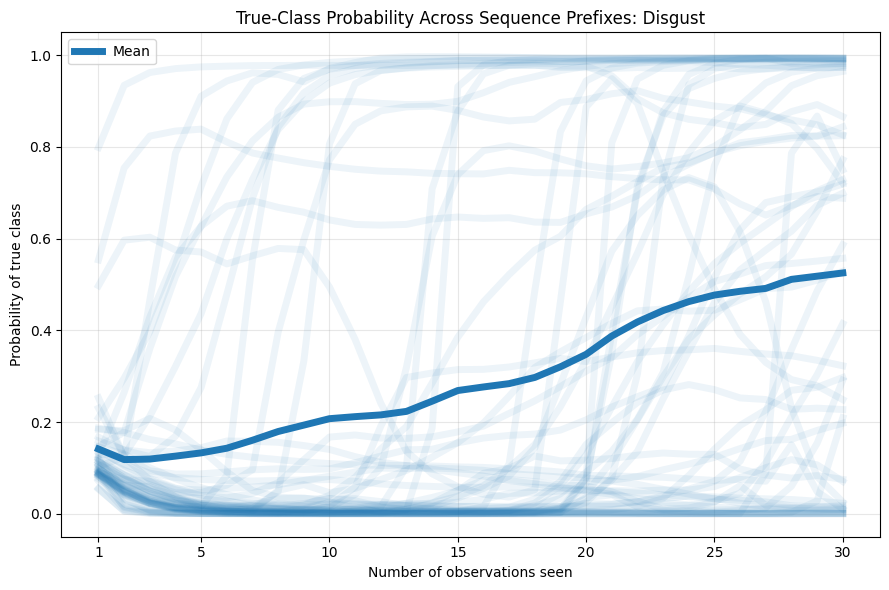

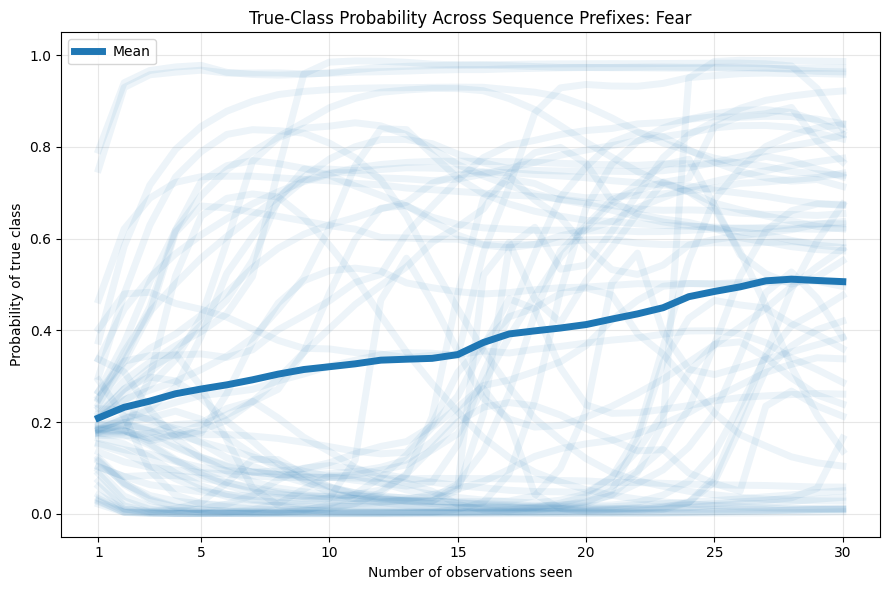

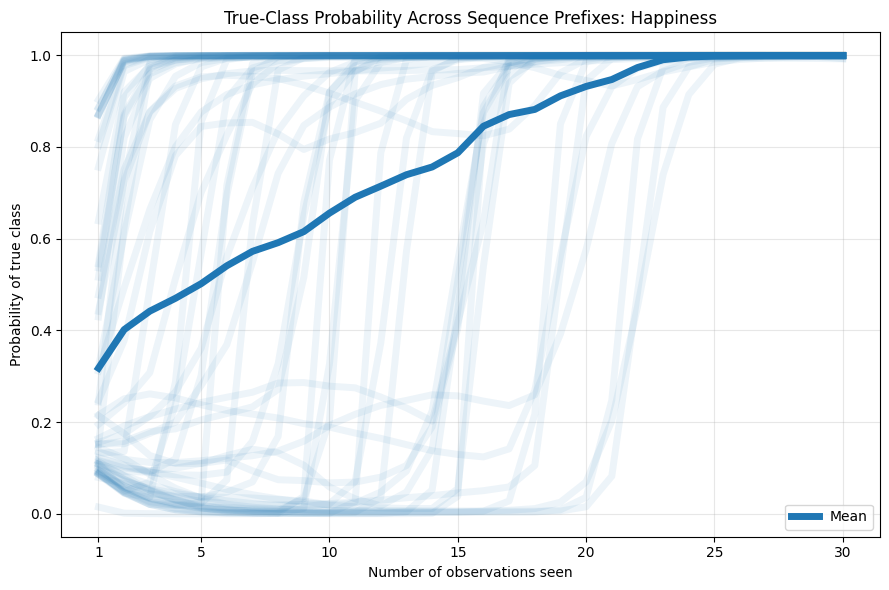

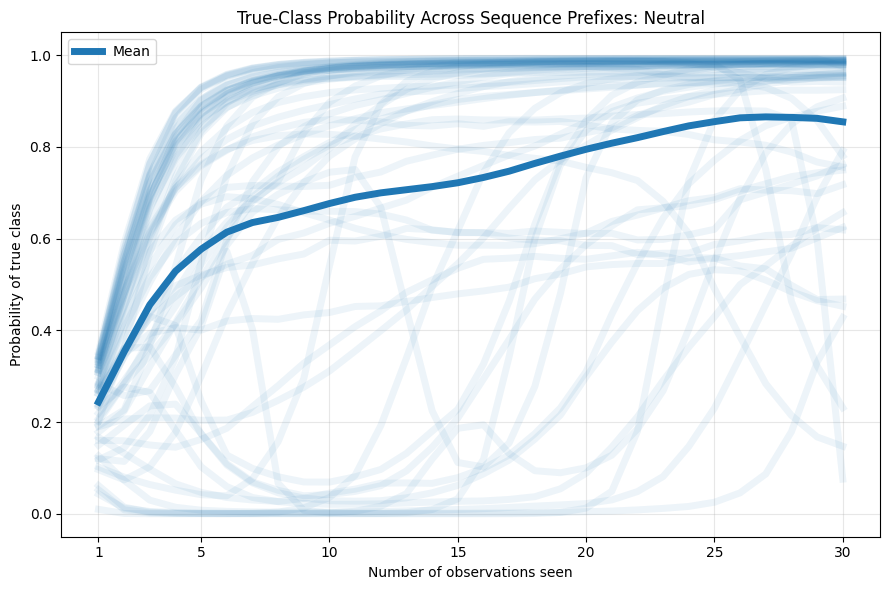

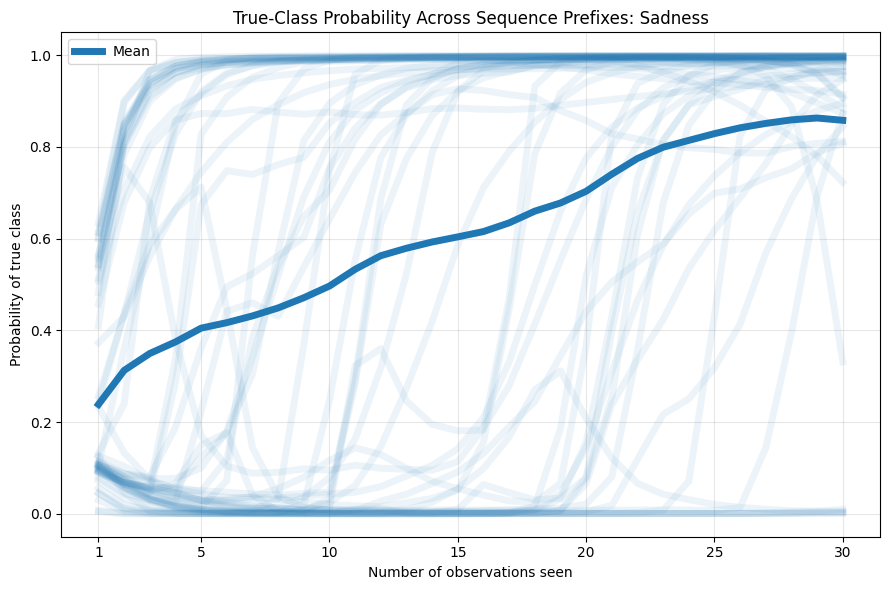

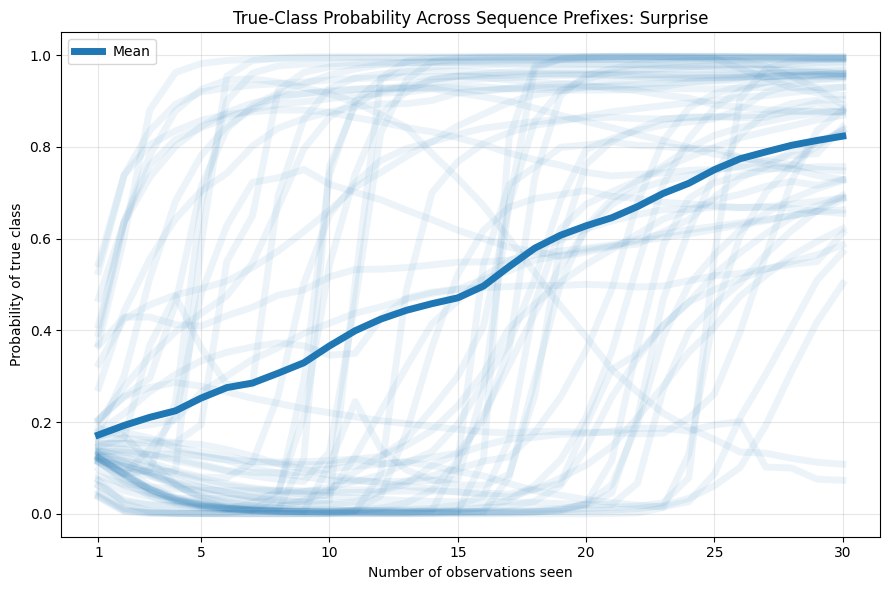

In [144]:
for class_name in id_to_emotion.values():
    plot_sample_true_class_trajectories(
        trajectory_df,
        class_name
    )